# PROJECT_NETFLIX_DATA_CLEARING & VISUALIZATION

In [1]:
import pandas as pd
data = pd.read_csv("netflix1.csv")

# Drop duplicates
data = data.drop_duplicates()

# Fill missing values
data['director'].replace('', 'Not Given', inplace=True)
data['country'].replace('', 'Not Given', inplace=True)

# Convert date_added to datetime
data['date_added'] = pd.to_datetime(data['date_added'])

In [2]:
import pandas as pd

# Load dataset (make sure file is in the same folder as notebook)
data = pd.read_csv("netflix1.csv")

# Show first 5 rows
data.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
# Remove duplicate rows
data = data.drop_duplicates()

# Fill missing values in specific columns
data['director'].fillna('Not Given', inplace=True)
data['country'].fillna('Not Given', inplace=True)

# Convert date column to datetime format
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')

# Check missing values after cleaning
print(data.isnull().sum())

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


# EDA VISUALIZATIONS

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set(style="whitegrid")


# Movies vs TV Shows

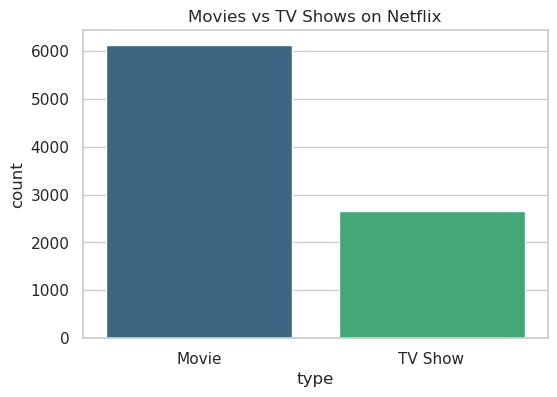

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=data, palette="viridis")
plt.title("Movies vs TV Shows on Netflix")
plt.show()

#### NETFLIX has more movies than TV Shows

# Ratings Distribution

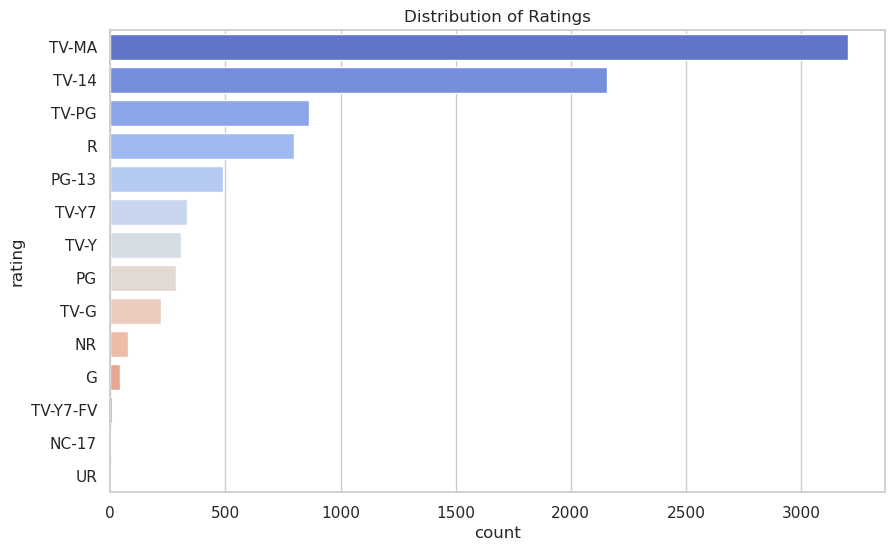

In [6]:
plt.figure(figsize=(10,6))
sns.countplot(y="rating", data=data, order=data['rating'].value_counts().index, palette="coolwarm")
plt.title("Distribution of Ratings")
plt.show()

#### TV-MA is the most common rating, meaning lots of mature content.

# Content added over years

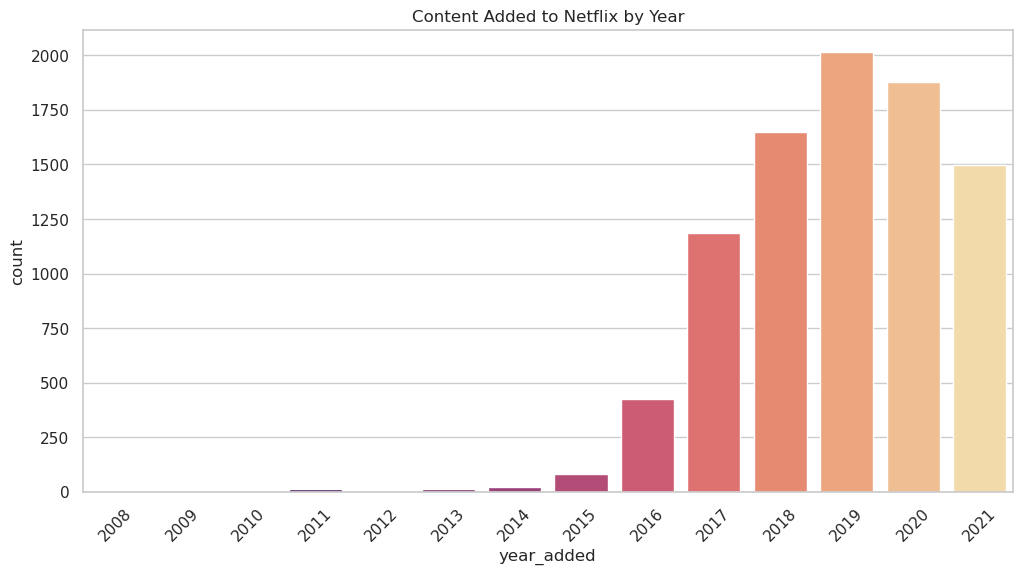

In [7]:
data['year_added'] = data['date_added'].dt.year

plt.figure(figsize=(12,6))
sns.countplot(x='year_added', data=data, palette="magma")
plt.xticks(rotation=45)
plt.title("Content Added to Netflix by Year")
plt.show()

#### peak growth is shown around 2017-2020

# Top 10 Countries with Most Content

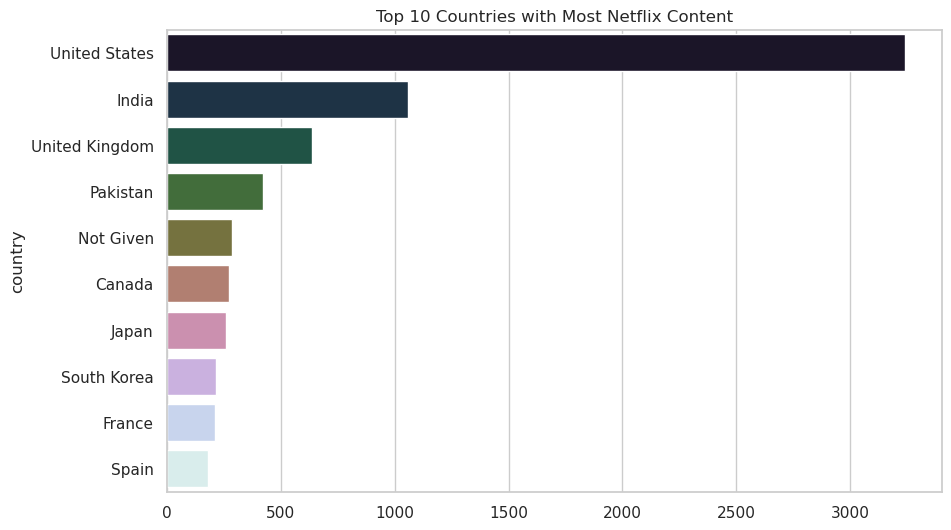

In [8]:
top_countries = data['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="cubehelix")
plt.title("Top 10 Countries with Most Netflix Content")
plt.show()

#### USA Dominates the content followed by India & UK

# Top 10 Genres

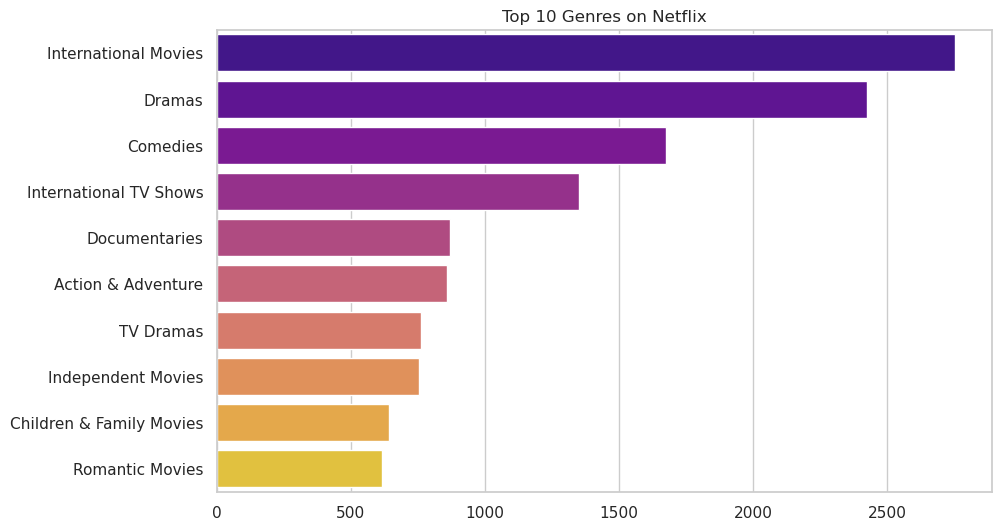

In [9]:
from collections import Counter

all_genres = data['listed_in'].dropna().str.split(',').sum()
genre_counts = Counter([g.strip() for g in all_genres])
top_genres = pd.Series(genre_counts).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="plasma")
plt.title("Top 10 Genres on Netflix")
plt.show()

#### International Movies, Dramas, Documentaries are most popular

# Monthly release

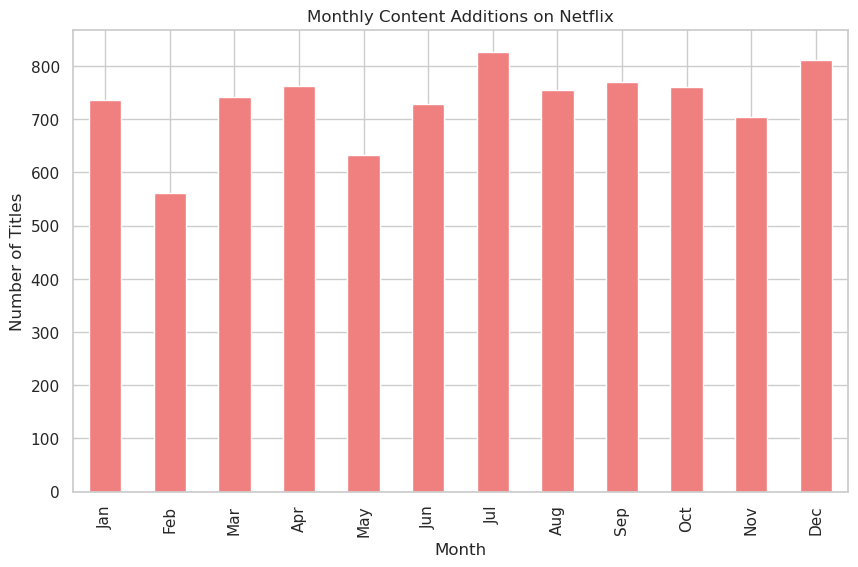

In [27]:
# Extract month from date_added
data['month_added'] = data['date_added'].dt.month

# Count releases per month
monthly_releases = data['month_added'].value_counts().sort_index()

# Month names
import calendar
monthly_releases.index = [calendar.month_abbr[m] for m in monthly_releases.index]

# Plot
plt.figure(figsize=(10,6))
monthly_releases.plot(kind='bar', color='lightcoral')
plt.title("Monthly Content Additions on Netflix")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.show()


#### Netflix tends to release more content around July and October–December (holiday seasons).

# Yearly release

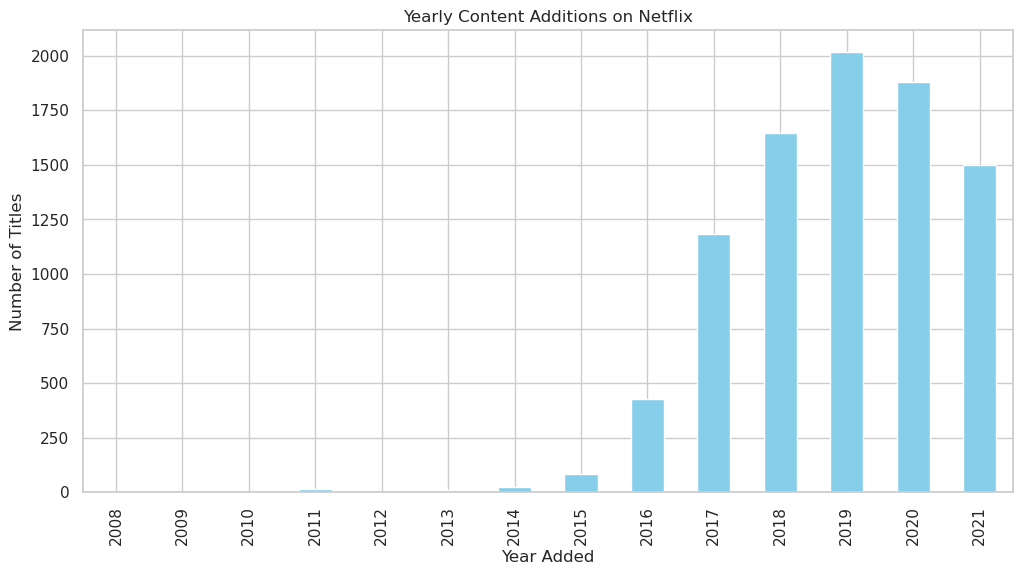

In [28]:
import matplotlib.pyplot as plt

# Extract year from date_added
data['year_added'] = data['date_added'].dt.year

# Count releases per year
yearly_releases = data['year_added'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12,6))
yearly_releases.plot(kind='bar', color='skyblue')
plt.title("Yearly Content Additions on Netflix")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()


#### Netflix saw rapid growth in content from 2015 to 2020, with the peak in 2019.

# Word Cloud of Movie Titles

In [10]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [11]:
import sys
!{sys.executable} -m pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [14]:
from wordcloud import WordCloud


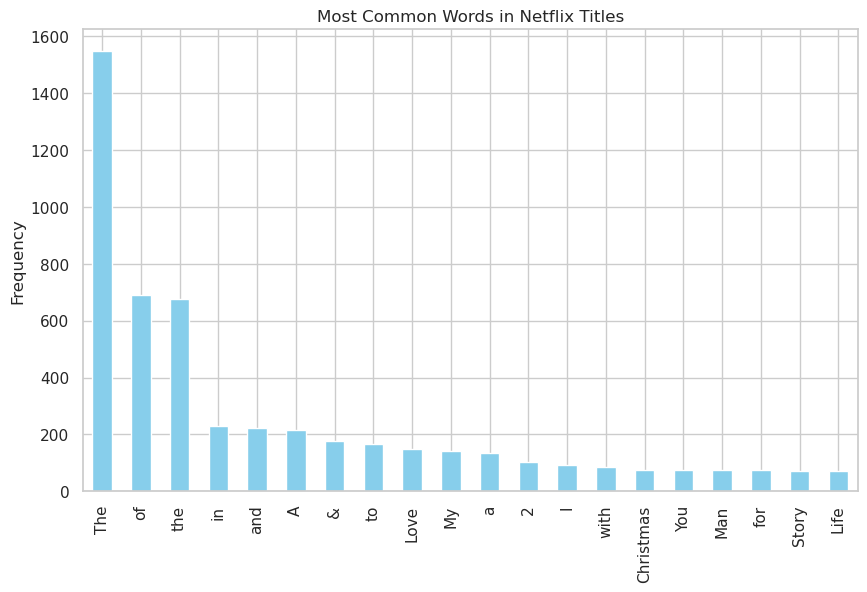

In [15]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

words = " ".join(data['title'].dropna()).split()
word_counts = Counter(words)
common_words = pd.Series(word_counts).sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
common_words.plot(kind='bar', color='skyblue')
plt.title("Most Common Words in Netflix Titles")
plt.ylabel("Frequency")
plt.show()


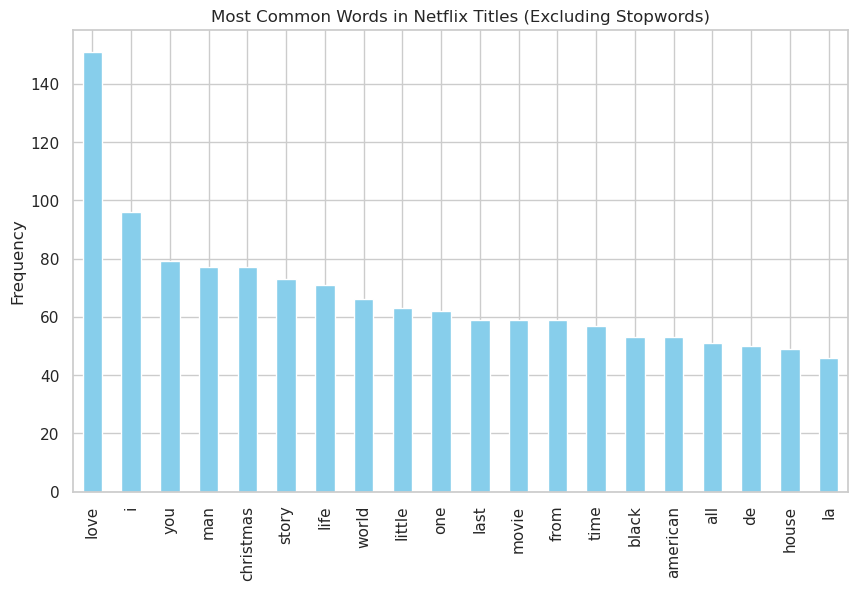

In [17]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Define stopwords (you can expand this list)
stopwords = {"the", "a", "of", "and", "in", "on", "to", "with", "for", "at", "by", "an","&","is","-","my","2","me"}

# Join all titles into one string, split into words
words = " ".join(data['title'].dropna()).split()

# Remove stopwords and make everything lowercase
filtered_words = [w.lower() for w in words if w.lower() not in stopwords]

# Count most common words
word_counts = Counter(filtered_words)
common_words = pd.Series(word_counts).sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(10,6))
common_words.plot(kind='bar', color='skyblue')
plt.title("Most Common Words in Netflix Titles (Excluding Stopwords)")
plt.ylabel("Frequency")
plt.show()


#### Love is the most used word for the titles of Netflix

In [18]:
from sklearn.preprocessing import LabelEncoder

# Copy dataset
df_ml = data.copy()

# Handle duration: convert "90 min" to 90
df_ml['duration_num'] = df_ml['duration'].str.extract('(\d+)').astype(float)

# Encode categorical features
le_type = LabelEncoder()
df_ml['type_encoded'] = le_type.fit_transform(df_ml['type'])   # Movie=1, TV Show=0

le_rating = LabelEncoder()
df_ml['rating_encoded'] = le_rating.fit_transform(df_ml['rating'].astype(str))

# Select features and target
X = df_ml[['release_year', 'duration_num', 'rating_encoded']]
y = df_ml['type_encoded']


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

dt = DecisionTreeClassifier(criterion='entropy', max_depth=5)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le_type.classes_))


Accuracy: 0.9977246871444824
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1238
     TV Show       0.99      1.00      1.00       520

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Accuracy (KNN):", accuracy_score(y_test, y_pred_knn))


Accuracy (KNN): 0.997155858930603


## Visualization for model accuracy comparision

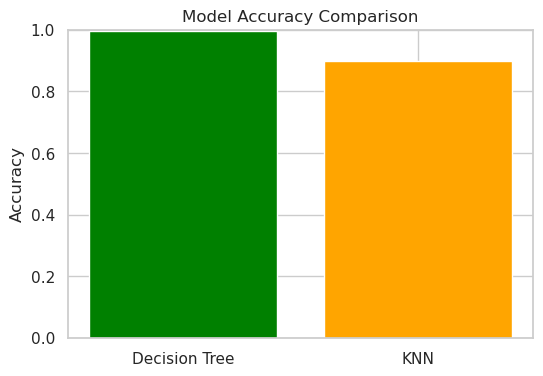

In [22]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'KNN']
accuracy = [0.997, 0.90]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy, color=['green','orange'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


# recommendation suggestion system

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd


In [24]:
# Fill missing genres
data['listed_in'] = data['listed_in'].fillna("")

# Convert text into a matrix of token counts
cv = CountVectorizer(stop_words='english')
genre_matrix = cv.fit_transform(data['listed_in'])

# Compute similarity matrix
cosine_sim = cosine_similarity(genre_matrix)


In [25]:
def recommend(title, n=5):
    # Find the index of the movie/TV show
    idx = data[data['title'].str.contains(title, case=False, na=False)].index
    
    if len(idx) == 0:
        return "Title not found in dataset."
    
    idx = idx[0]
    
    # Get similarity scores for all titles
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get top n recommendations (excluding the title itself at index 0)
    sim_scores = sim_scores[1:n+1]
    
    # Return recommended titles
    recommendations = data.iloc[[i[0] for i in sim_scores]]['title']
    return recommendations.tolist()


### testing the recommendation system

In [26]:
print(recommend("Breaking Bad", 5))
print(recommend("Money Heist", 5))


['Freedomland', 'The Lincoln Lawyer', 'The American', 'Awake', 'The Woman in the Window']
['Especial 20 años Fútbol de Primera', 'Camarón Revolution', 'Nuestra Lucha Libre', 'The Least Expected Day: Inside the Movistar Team 2019', 'Nevenka: Breaking the Silence']
